<a href="https://colab.research.google.com/github/2023006766/deep-learning/blob/main/Lenet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2323 - val_loss: 0.1507
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1346 - val_loss: 0.1210
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1157 - val_loss: 0.1086
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1069 - val_loss: 0.1027
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1024 - val_loss: 0.0995
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0998 - val_loss: 0.0973
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0978 - val_loss: 0.0955
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0960 - val_loss: 0.0940
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0946 - val_loss: 0.0935
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0937 - val_loss: 0.0921
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0929 - val_los

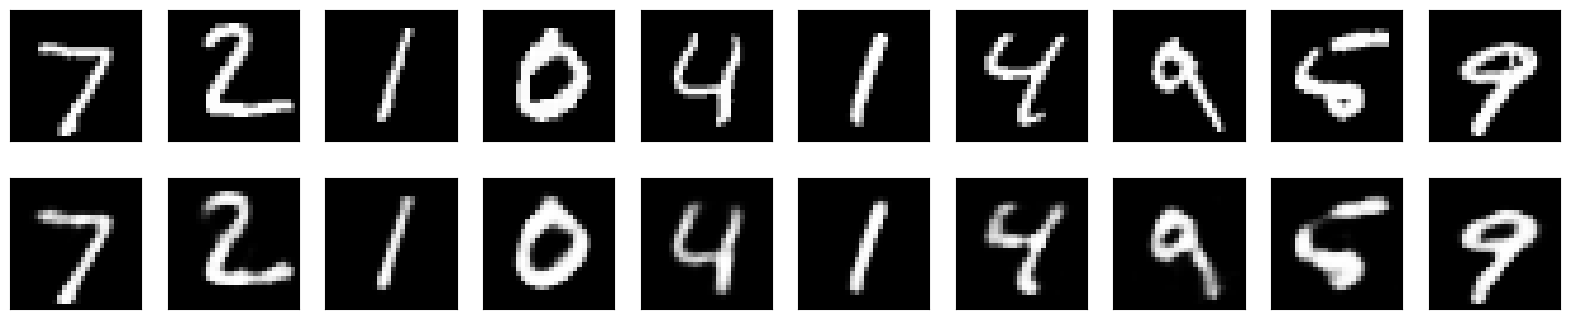

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Preprocess Data
(train_x, _), (test_x, _) = mnist.load_data()

# Normalize pixel values and flatten 28x28 images to 784 vectors
train_x = train_x.astype('float32') / 255.0
test_x = test_x.astype('float32') / 255.0
train_x = train_x.reshape((len(train_x), np.prod(train_x.shape[1:])))
test_x = test_x.reshape((len(test_x), np.prod(test_x.shape[1:])))

# 2. Autoencoder Architecture
input_size = 784
hidden_size = 128
code_size = 32  # Compression factor of ~24.5

input_img = Input(shape=(input_size,))

# Encoder
hidden_1 = Dense(hidden_size, activation='relu')(input_img)
code = Dense(code_size, activation='relu')(hidden_1)

# Decoder
hidden_2 = Dense(hidden_size, activation='relu')(code)
output_img = Dense(input_size, activation='sigmoid')(hidden_2)

# Full Model
autoencoder = Model(input_img, output_img)

# 3. Compilation and Training
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(train_x, train_x,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(test_x, test_x))

# 4. Visualization of Results
reconstructed_imgs = autoencoder.predict(test_x)

n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_x[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()